# Ejercicio 6 – Parquet versus tablas DuckDB

En este notebook se comparan dos estrategias para consultar los viajes de taxi con DuckDB:

| Estrategia | Qué es `viajes` | Qué ocurre en cada consulta |
|------------|-----------------|-----------------------------|
| **parquet** | La vista `sql/04_eda/00_vista_viajes.sql` | DuckDB lee los archivos Parquet, une amarillos y verdes y aplica los filtros de calidad. |
| **tabla** | Una tabla dentro de una base `.duckdb` | DuckDB lee los datos ya unificados y filtrados, guardados en su propio formato. |

Las mediciones se realizan con el script `scripts/benchmark.py`, que se ejecuta desde la terminal porque tarda varios minutos:

```bash
docker compose exec lab python scripts/benchmark.py --recrear
```

El script guarda los resultados en `docs/benchmark/` y este notebook los lee y los analiza. Las condiciones de la medición son:

- ambas estrategias usan la misma configuración: `memory_limit = 1GB`, `threads = 2`;
- cada consulta se ejecuta **3 veces** por estrategia y se usa la **mediana**;
- los tiempos incluyen la ejecución completa de la consulta y la obtención de todas sus filas.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Se trabaja desde la raiz del proyecto
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, "scripts")
import benchmark  # scripts/benchmark.py

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

COLORES = {"parquet": "#1F77B4", "tabla": "#D62728"}

## 6.1–6.2 Estrategias y volúmenes de datos

La tabla materializada se crea con `sql/06_benchmark/crear_tabla.sql`. El script conecta la base destino con `ATTACH` y guarda en ella el resultado de la vista `viajes`:

In [2]:
print(Path("sql/06_benchmark/crear_tabla.sql").read_text())

-- Ejercicio 6.2 - Materializa la vista `viajes` como tabla en una base DuckDB.
-- Requiere: vista `viajes` (sql/04_eda/00_vista_viajes.sql) y la base destino adjunta como `destino`
--   (ATTACH 'data/processed/<archivo>.duckdb' AS destino).
-- Resultado: tabla destino.viajes con los viajes unificados y filtrados.
CREATE OR REPLACE TABLE destino.viajes AS
SELECT *
FROM viajes;



In [3]:
pd.Series(benchmark.VOLUMENES, name="patron de archivos (data/raw/<tipo>/...)").to_frame()

,patron de archivos (data/raw/<tipo>/...)
1_mes,2026/*_2026-01.parquet
2026,2026/*.parquet
2024_2026,202[46]/*.parquet


Para observar cómo cambia el comportamiento con la cantidad de datos (6.6), se usan **tres volúmenes**. Cada uno restringe los patrones de archivos de la vista y tiene su propia base materializada (`data/processed/benchmark_<volumen>.duckdb`).

## 6.3 y 6.8 Consultas del benchmark

Se seleccionaron cinco consultas del Ejercicio 4 que representan distintos tipos de trabajo:

| Consulta | Tipo de trabajo |
|----------|-----------------|
| `02_viajes_por_mes` | Agregación simple (conteo por grupo). |
| `03_viajes_hora_dia` | Agregación con extracción de fecha y función de ventana. |
| `04_caracteristicas_viaje` | Cálculo intensivo: percentiles aproximados de cuatro métricas. |
| `06_forma_pago` | Agregación con `CASE` y función de ventana. |
| `09_atipicos` | Dos recorridos de los datos (CTE de límites + `JOIN`) con varios filtros. |

El mismo texto SQL se ejecuta con ambas estrategias; solo cambia a qué se refiere `viajes` en cada conexión:

In [4]:
for ruta in benchmark.CONSULTAS:
    print("=" * 100)
    print(ruta)
    print("=" * 100)
    print(Path(ruta).read_text())

sql/04_eda/02_viajes_por_mes.sql
-- P1 - Viajes por mes y tipo de taxi, con promedio diario.
-- Fuente: vista `viajes`.
SELECT
    periodo,
    tipo,
    count(*)                                                 AS viajes,
    round(count(*) / count(DISTINCT pickup_datetime::DATE), 0) AS viajes_por_dia
FROM viajes
GROUP BY periodo, tipo
ORDER BY tipo, periodo;

sql/04_eda/03_viajes_hora_dia.sql
-- P2 - Porcentaje de los viajes de cada tipo de taxi por dia de la semana y hora de inicio.
-- Fuente: vista `viajes`. dia_semana: 1 = lunes ... 7 = domingo (ISO).
SELECT
    tipo,
    isodow(pickup_datetime)                                        AS dia_semana,
    hour(pickup_datetime)                                          AS hora,
    count(*)                                                       AS viajes,
    100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo)      AS pct_viajes
FROM viajes
GROUP BY tipo, dia_semana, hora
ORDER BY tipo, dia_semana, hora;

sql/04_eda/04_caracteristi

## Costo de materializar la tabla

`docs/benchmark/materializacion.csv` registra, por volumen, el tamaño de los archivos Parquet, el tamaño de la base DuckDB y el tiempo de creación de la tabla.

In [5]:
materializacion = pd.read_csv("docs/benchmark/materializacion.csv")
materializacion = materializacion.set_index("volumen").loc[list(benchmark.VOLUMENES)]
materializacion["mb_parquet"] = (materializacion["bytes_parquet"] / 1024**2).round(1)
materializacion["mb_duckdb"] = (materializacion["bytes_duckdb"] / 1024**2).round(1)
materializacion["duckdb_vs_parquet"] = (materializacion["bytes_duckdb"] / materializacion["bytes_parquet"]).round(2)
materializacion[["archivos", "registros", "mb_parquet", "mb_duckdb", "duckdb_vs_parquet", "segundos_creacion"]]

,archivos,registros,mb_parquet,mb_duckdb,duckdb_vs_parquet,segundos_creacion
volumen,,,,,,
1_mes,2,3556866,62.1,121.5,1.96,5.05
2026,16,28566965,495.7,968.0,1.95,37.46
2024_2026,40,69021014,1171.7,2293.3,1.96,80.80


**Resultado:**

- Crear la tabla tomó **5 s** (1 mes), **37 s** (2026) y **81 s** (2024 + 2026). El tiempo crece de forma proporcional al número de registros.
- La base DuckDB ocupa **casi el doble** que los Parquet originales (2,293 MB frente a 1,172 MB en el volumen mayor), aunque solo contiene los viajes filtrados. Parquet comprime más que el formato de almacenamiento de DuckDB.
- Materializar duplica los datos en disco: los Parquet originales se conservan y la tabla es una copia adicional.

## 6.4, 6.5 y 6.7 Tiempos de ejecución

La primera tabla muestra la mediana de cada consulta y cuántas veces más lenta es en Parquet que en la tabla (`parquet / tabla`). La segunda suma las cinco consultas por volumen.

In [6]:
tiempos = pd.read_csv("docs/benchmark/tiempos.csv")
tabla = (
    tiempos.groupby(["volumen", "consulta", "estrategia"])["segundos"].median()
    .unstack("estrategia")
    .reindex(list(benchmark.VOLUMENES), level="volumen")
)
tabla["parquet / tabla"] = (tabla["parquet"] / tabla["tabla"]).round(1)
tabla.round(2)

estrategia                          parquet  tabla  parquet / tabla
volumen   consulta                                                 
1_mes     02_viajes_por_mes            0.53   0.08              6.9
          03_viajes_hora_dia           0.51   0.16              3.2
          04_caracteristicas_viaje     1.08   0.52              2.1
          06_forma_pago                0.51   0.14              3.6
          09_atipicos                  1.88   1.02              1.8
2026      02_viajes_por_mes            3.99   0.65              6.2
          03_viajes_hora_dia           5.05   1.02              5.0
          04_caracteristicas_viaje     9.06   5.74              1.6
          06_forma_pago                3.71   1.10              3.4
          09_atipicos                 13.51   5.16              2.6
2024_2026 02_viajes_por_mes            9.18   2.23              4.1
          03_viajes_hora_dia           8.65   2.54              3.4
          04_caracteristicas_viaje    21.88  10.29              2.1
          06_forma_pago               10.13   2.92              3.5
          09_atipicos                 37.34  18.28              2.0

In [7]:
resumen = tabla.groupby(level="volumen", sort=False)[["parquet", "tabla"]].sum()
resumen["parquet / tabla"] = (resumen["parquet"] / resumen["tabla"]).round(1)
resumen = resumen.join(materializacion["registros"])
resumen.round(2)

,parquet,tabla,parquet / tabla,registros
volumen,,,,
1_mes,4.51,1.92,2.3,3556866
2026,35.33,13.66,2.6,28566965
2024_2026,87.19,36.26,2.4,69021014


**Resultado:**

- La **tabla es más rápida en las 15 combinaciones** de consulta y volumen: entre 1.6 y 6.9 veces.
- Sumando las cinco consultas, la tabla es **2.3–2.6 veces más rápida** en los tres volúmenes. Con 2024 + 2026, por ejemplo, tarda 36 s frente a 87 s.
- La mayor diferencia aparece en las **agregaciones simples**: `02_viajes_por_mes` es 4–7 veces más rápida en tabla.
- La menor diferencia aparece en las **consultas de cálculo intensivo**: `04_caracteristicas_viaje` y `09_atipicos` son solo ~2 veces más rápidas.

## 6.6 Comportamiento según la cantidad de datos

El primer gráfico muestra el tiempo de cada consulta según el número de registros (ambos ejes en escala logarítmica). El segundo muestra la relación `parquet / tabla` en cada volumen.

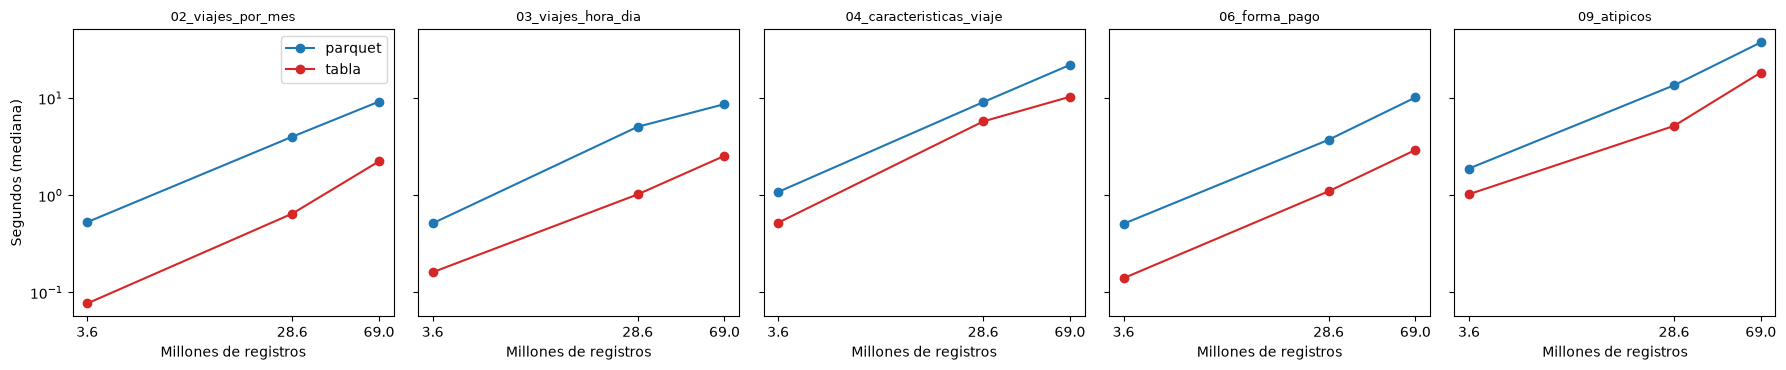

In [8]:
medianas = tiempos.groupby(["volumen", "consulta", "estrategia"])["segundos"].median().reset_index()
medianas = medianas.merge(materializacion["registros"].reset_index(), on="volumen")

consultas = list(dict.fromkeys(Path(c).stem for c in benchmark.CONSULTAS))
fig, ejes = plt.subplots(1, len(consultas), figsize=(18, 3.8), sharey=True)
for eje, consulta in zip(ejes, consultas):
    for estrategia in ["parquet", "tabla"]:
        datos = medianas[(medianas["consulta"] == consulta) & (medianas["estrategia"] == estrategia)].sort_values("registros")
        eje.plot(datos["registros"] / 1e6, datos["segundos"], marker="o", color=COLORES[estrategia], label=estrategia)
    eje.set_title(consulta, fontsize=9)
    eje.set_xscale("log")
    eje.set_yscale("log")
    eje.minorticks_off()
    valores = sorted(materializacion["registros"] / 1e6)
    eje.set_xticks(valores, [f"{v:.1f}" for v in valores])
    eje.set_xlabel("Millones de registros")
ejes[0].set_ylabel("Segundos (mediana)")
ejes[0].legend()
plt.tight_layout()
plt.show()

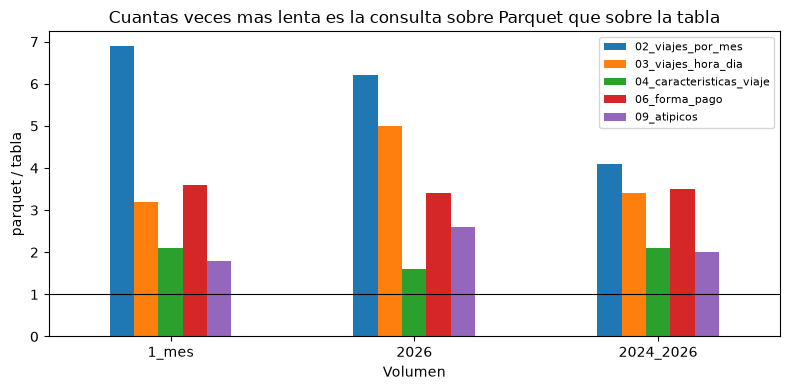

In [9]:
fig, eje = plt.subplots(figsize=(8, 4))
tabla["parquet / tabla"].unstack("consulta").loc[list(benchmark.VOLUMENES)].plot.bar(ax=eje, rot=0)
eje.axhline(1, color="black", linewidth=0.8)
eje.set_title("Cuantas veces mas lenta es la consulta sobre Parquet que sobre la tabla")
eje.set_xlabel("Volumen")
eje.set_ylabel("parquet / tabla")
eje.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Resultado:**

- En ambas estrategias el tiempo crece **casi proporcionalmente** al número de registros: las líneas son prácticamente paralelas.
  - Al pasar de 1 mes a 2026 (8 veces más registros), el tiempo total aumenta 7.8 veces en Parquet y 7.1 veces en tabla.
  - Al pasar de 2026 a 2024 + 2026 (2.4 veces más registros), aumenta 2.5 y 2.7 veces.
- La ventaja de la tabla se mantiene en todos los volúmenes, pero en `02_viajes_por_mes` **se reduce con el volumen mayor** (de 6.9 a 4.1 veces). Con 2024 + 2026, la base (2.3 GB) ya no cabe en el límite de memoria de 1 GB, y DuckDB debe volver a leer la tabla desde el disco en cada consulta.

## Primera ejecución frente a las siguientes

Se compara el tiempo total de la primera repetición con el promedio de las repeticiones 2 y 3.

In [10]:
primera = tiempos[tiempos["repeticion"] == 1].groupby(["volumen", "estrategia"])["segundos"].sum()
siguientes = tiempos[tiempos["repeticion"] > 1].groupby(["volumen", "estrategia", "repeticion"])["segundos"].sum().groupby(["volumen", "estrategia"]).mean()
pd.DataFrame({"primera_rep": primera, "promedio_reps_siguientes": siguientes}).reindex(list(benchmark.VOLUMENES), level="volumen").round(2)

primera_rep  promedio_reps_siguientes
volumen   estrategia                                       
1_mes     parquet            4.47                      4.72
          tabla              2.23                      1.90
2026      parquet           36.71                     36.19
          tabla             16.88                     12.88
2024_2026 parquet           91.05                     87.68
          tabla             41.66                     34.57

**Resultado:**

- Con **tabla**, la primera repetición es más lenta (por ejemplo, 41.7 s frente a 34.6 s en 2024 + 2026): en la primera consulta DuckDB carga los bloques de la base desde el disco y en las siguientes reutiliza los que quedaron en memoria.
- Con **Parquet** no hay diferencia apreciable (91.1 s frente a 87.7 s): en cada consulta los archivos se vuelven a leer y descomprimir.

## 6.9 Análisis de las diferencias

1. **Trabajo repetido en Parquet.** Con la estrategia Parquet, cada consulta vuelve a leer y descomprimir los archivos, unir amarillos y verdes, extraer el periodo del nombre del archivo y aplicar los filtros de calidad. En la tabla ese trabajo se hizo una sola vez, al materializarla.
2. **La ventaja depende del tipo de consulta.** En una agregación simple casi todo el tiempo se va en leer y preparar los datos, así que la tabla gana por mucho (4–7 veces). En consultas de cálculo intensivo (percentiles, dos recorridos con `JOIN`) la mayor parte del tiempo es cálculo, igual en ambas estrategias, y la ventaja baja a ~2 veces.
3. **Escalabilidad similar.** Ambas estrategias crecen de forma lineal con el número de registros. DuckDB procesa ambos formatos por columnas y en bloques, por lo que ninguna se degrada al aumentar los datos.
4. **La memoria limita la ventaja de la tabla.** Cuando la base no cabe en la memoria asignada (volumen 2024 + 2026), la tabla también depende de la lectura del disco y su ventaja en consultas simples disminuye.
5. **Costo de la tabla.** Materializar tomó 81 s y ocupa el doble de espacio que los Parquet. Con el volumen mayor, una sola ejecución del conjunto de consultas ahorra 51 s (87 s → 36 s), así que el costo de creación se recupera después de **dos ejecuciones** del análisis.